In [6]:
import pandas as pd
df=pd.read_csv('/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
print("Rows and columns:",df.shape)
print("\nData types:\n",df.dtypes)
print("Missing values:\n",df.isnull().sum())
print("\nDuplicated rows:",df.duplicated().sum())


Rows and columns: (8807, 12)

Data types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
Missing values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicated rows: 0


In [9]:
df['director']=df['director'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')

df=df.dropna(subset=['date_added','rating','duration',])

print("New shape:",df.shape)
print("\nRemaining missing values:\n",df.isnull().sum())

New shape: (8790, 12)

Remaining missing values:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [11]:
df['date_added']=pd.to_datetime(df['date_added'].str.strip(),format='mixed')
print(df['date_added'].dtype)

datetime64[ns]


**Question 1: Are there more Movies or TV Shows?**

In [12]:
print(df['type'].value_counts())

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


**Question 2: Which countries produce the most content?**

In [14]:
print(df['country'].value_counts().head(10))

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


**Question 3: How has content added to Netflix changed over the years?**

In [15]:
df['year_added'] = df['date_added'].dt.year
print(df['year_added'].value_counts().sort_index())

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


**Question 4: What are the most common ratings (like TV-MA, PG-13)?**

In [16]:
print(df['rating'].value_counts())

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


**Question 5: What are the most common genres?**

In [17]:
print(df['listed_in'].value_counts().head(10))

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

**Chart 1: Movies vs TV Shows**

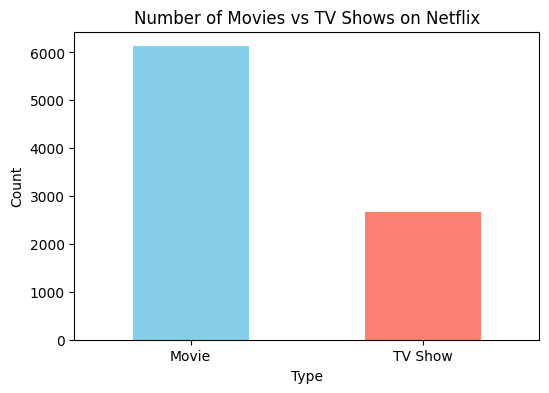

In [19]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('Number of Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Chart 2: Top 10 Content-Producing Countries**

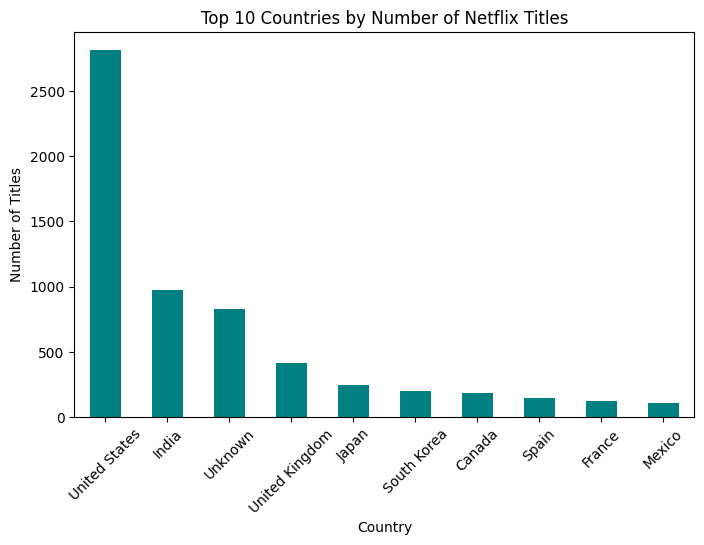

In [20]:
plt.figure(figsize=(8,5))
df['country'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Number of Netflix Titles')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

**Chart 3: Netflix Content Growth Over Time**

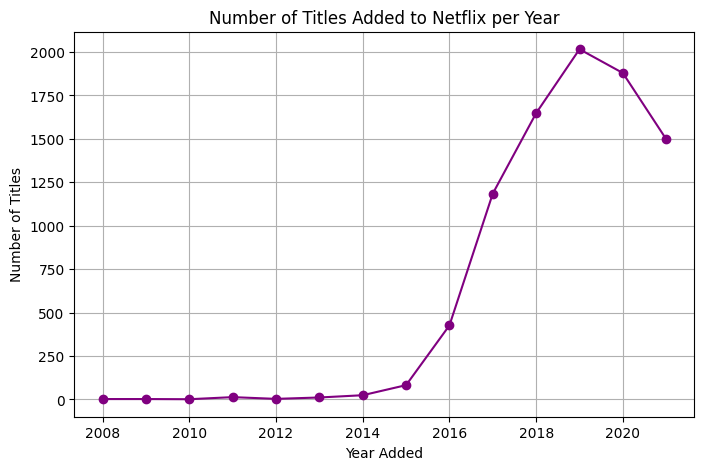

In [23]:
plt.figure(figsize=(8,5))
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='purple')
plt.title('Number of Titles Added to Netflix per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(1)
plt.show()

**Chart 4: Distribution of Content Ratings**

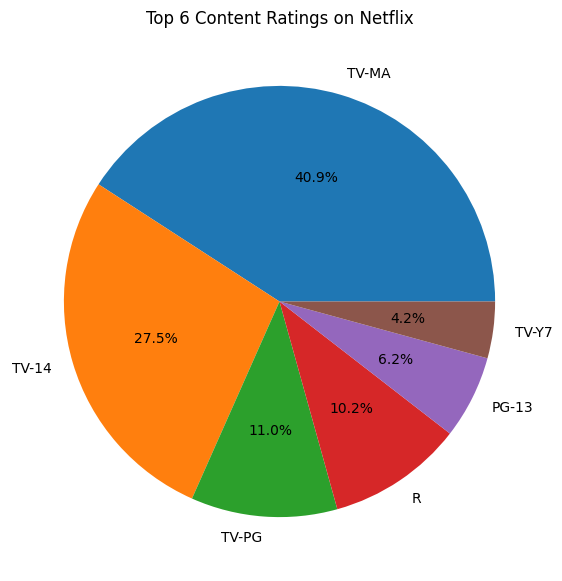

In [24]:
plt.figure(figsize=(7,7))
df['rating'].value_counts().head(6).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 6 Content Ratings on Netflix')
plt.ylabel('')
plt.show()

**Chart 5: Movie durations**

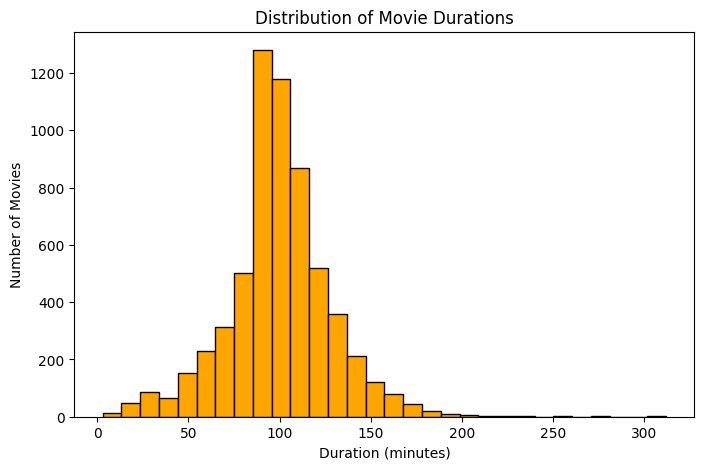

In [25]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(8,5))
movies['duration_min'].plot(kind='hist', bins=30, color='orange', edgecolor='black')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.show()

**Chart 6: Correlation between numeric columns**

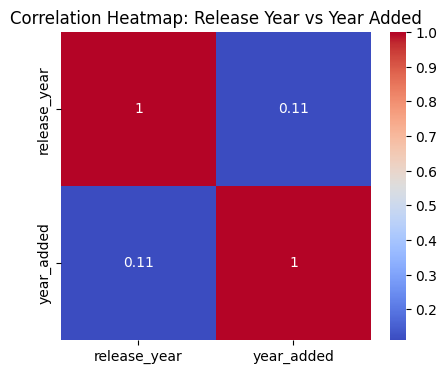

In [26]:
numeric_df = df[['release_year', 'year_added']].copy()
plt.figure(figsize=(5,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Release Year vs Year Added')
plt.show()

**Chart 7 (Bonus): Movie Release Year vs Duration**

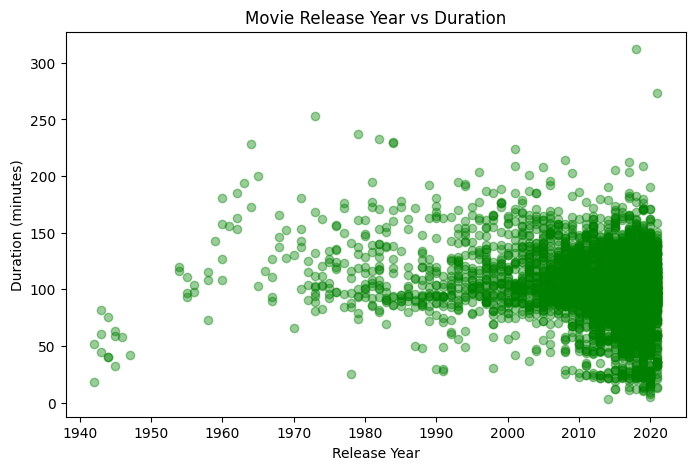

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(movies['release_year'], movies['duration_min'], alpha=0.4, color='green')
plt.title('Movie Release Year vs Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.show()

**Insights Report**



*   Netflix has way more movies than TV shows on it — 6,126 movies vs only 2,664 shows. I didn't realize the gap was that big until I saw Chart 1. Makes sense though, since movies are probably cheaper/easier for them to license in bulk compared to committing to whole seasons of a show.

*   The US completely dominates where the content comes from — almost 2,809 titles, more than double India which came in second (Chart 2). I expected it to be more spread out honestly, given Netflix markets itself as a global platform.

*  Looking at Chart 3, there's basically nothing on Netflix before 2015, and then it just explodes — jumps to over 2,000 titles added in 2019 alone. Then it drops off a bit in 2020-2021, which I'm guessing is COVID messing with production schedules.

*  TV-MA is by far the most common rating (3,205 titles), way ahead of TV-14 in second place (Chart 4). So the catalog is definitely leaning more toward mature/adult content than family-friendly stuff.


*   Most movie runtimes bunch up right around 90-100 minutes based on the histogram (Chart 5) — pretty much the standard movie length everywhere, no big surprises there, just confirms Netflix follows typical film conventions.




**What Surprised Me Most**

What surprised me most was how few titles there were before 2015 — almost nothing, then it just took off. I guess Netflix's whole "original content" push really only kicked into gear in the mid-2010s, before that they were mostly just a streaming library for other people's stuff.
